In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct, idct
# plt.style.use('mplstyle')

In [2]:
# Theoretical continuous power spectrum: P(k) ∝ k^-n
n = 3.0
N = 768                # number of channels
dnuc = 40e-3            # MHz spacing (example)
rp = 16.98990953034521 # Mpc/MHz              # Mpc/Hz conversion
dL = dnuc * rp      
L = N*dL # LOS length # volume in 3D
# r = 9209.71452683092
vfac = dL*(N-1)
# vfac = rp*r*r*dnuc*(N-1) # DCT factor


# continuous model grid for reference
k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

print(f"grid size = {dL:.3f} Mpc")
print(f"LOS length = {L:.3f} Mpc")

grid size = 0.680 Mpc
LOS length = 521.930 Mpc


In [3]:
def draw_field_from_power(P_dft):
    fk = np.zeros(N, dtype=complex)

    fk[0] = np.sqrt(P_dft[0]) * np.random.randn()
    # fk[0] = 0 * 1j*0
    if N % 2 == 0:
        fk[N//2] = np.sqrt(P_dft[N//2]) * np.random.randn()

    for i in range(1, N//2):
        a, b = np.random.randn(), np.random.randn()
        amp = np.sqrt(P_dft[i]/2)
        fk[i] = amp*(a + 1j*b)
        fk[-i] = np.conjugate(fk[i])

    return np.fft.ifft(fk).real

def bin_linear(x, y, nbins):
    bins = np.linspace(min(x), max(x), nbins+1)
    out = []
    xc = []
    for i in range(nbins):
        mask = (x >= bins[i]) & (x < bins[i+1])
        if np.sum(mask)>0:
            out.append(np.mean(y[mask]))
            xc.append(np.mean(x[mask]))
    return np.array(xc), np.array(out)


In [4]:
k_fft = 2*np.pi*np.arange(N)/(L) 
k_dct = np.pi*np.arange(N)/(L) # dct gives only positive frequencies 

k_abs = np.abs(k_fft)
P_cont = np.interp(k_abs, k_model, P_model, left=0, right=0)
# P_dft = P_cont*L
P_dft = (N**2 / L) * P_cont    # correct discrete variance for FFT modes

Nrea = 100
fields = np.array([draw_field_from_power(P_dft) for _ in range(Nrea)])/L


In [5]:
flag = np.ones(N) # pfunc.flagdata(N, mode='NOFLAG', percent = 10) # RANDOM, MWA, NOFLAG
ml = pfunc.covtocl_fast(flag, flag) # counter for normalizition 

w = windows.nuttall(2*N)[N:]
pk_recovered = []


for field in fields:

    # cl = pfunc.covtocl_fast(field, field)/ml    
    # pk_dct = dL * idct(cl.real*w, type=1)*N*N  # multiply by 2 for positive modes
    
    # pk_recovered.append(pk_dct)

    fk = np.fft.fft(field)/N 
    pk_fft = fk*np.conjugate(fk) * L**3
    pk_recovered.append(pk_fft)
    
pk_recovered = np.array(pk_recovered)


# binning 
NB = 32  # number of bins

# Build consistent bins based on FFT k-range (skip k=0)
n1 = 10
nend = N//2
k_vals = k_abs[n1:nend]
bins = np.linspace(k_vals.min(), k_vals.max(), NB+1)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# Prepare storage
binned_rec = np.zeros((Nrea, NB))

# --- Bin each realization individually ---
for i in range(Nrea):
    for j in range(NB):
        mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
        if np.any(mask):
            binned_rec[i, j] = np.mean(pk_recovered[i, n1:nend][mask])
        else:
            binned_rec[i, j] = np.nan

# Ensemble statistics
p_rec_mean = np.nanmean(binned_rec, axis=0)
p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)

# --- Bin the theory using the same bins ---
binned_th = np.zeros(NB)
for j in range(NB):
    mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
    if np.any(mask):
        binned_th[j] = np.mean(P_cont[n1:nend][mask])
    else:
        binned_th[j] = np.nan

        
plt.figure(figsize=(7,6))
plt.errorbar(k_centers, abs(p_rec_mean), p_rec_err, fmt='o',ls='--', label='Recovered (mean ± error)')
plt.plot(k_centers, binned_th, '-k', lw=2, label='Theory (window-matched)')
plt.plot(k_centers, k_centers**(-n), '-m', lw=2, label='Theory (window-matched)')
plt.xscale('log');
plt.yscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel(r'$P(k_\parallel)$')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Ratio plot
plt.figure(figsize=(7,4))
plt.axhline(1.0, color='k', ls='--')
err = p_rec_mean / binned_th - 1
plt.plot(k_centers, 100*err, 'o-')
plt.xscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel('Recovered / Theory')
plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_29206/3042813647.py:40: ComplexWarning: Casting complex values to real discards the imaginary part
  binned_rec[i, j] = np.mean(pk_recovered[i, n1:nend][mask])


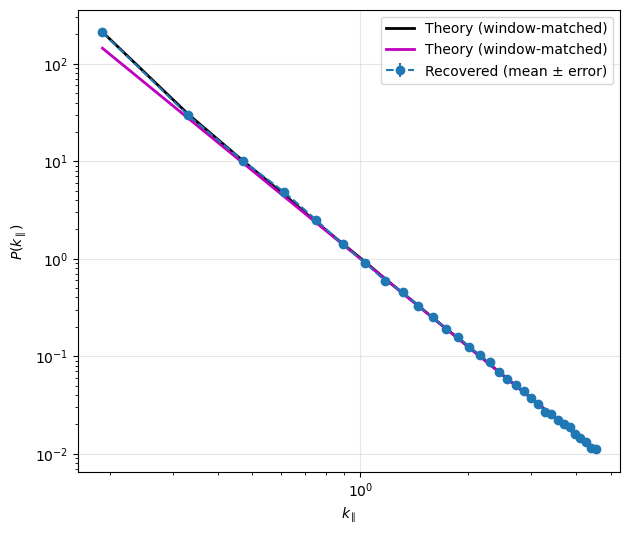

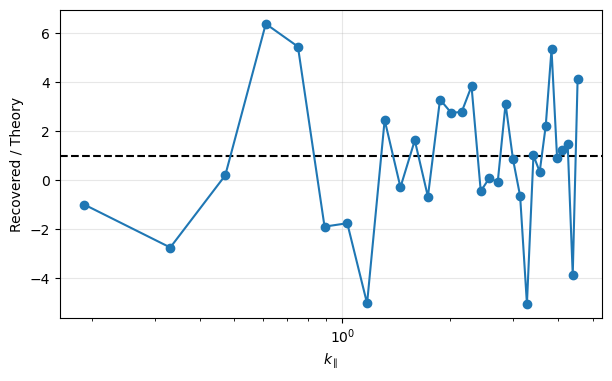

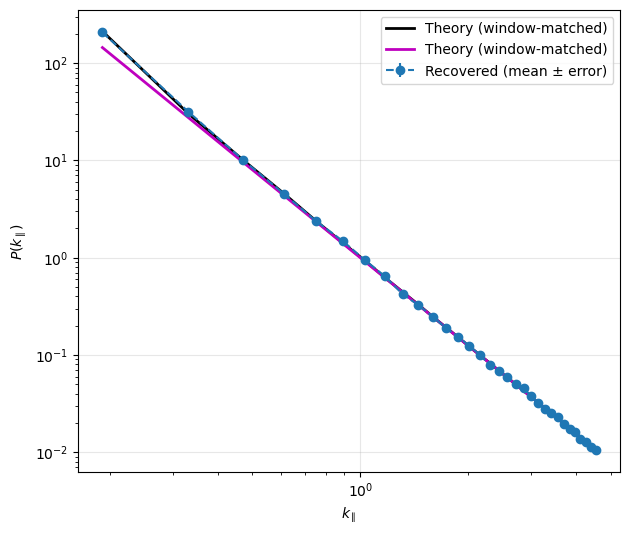

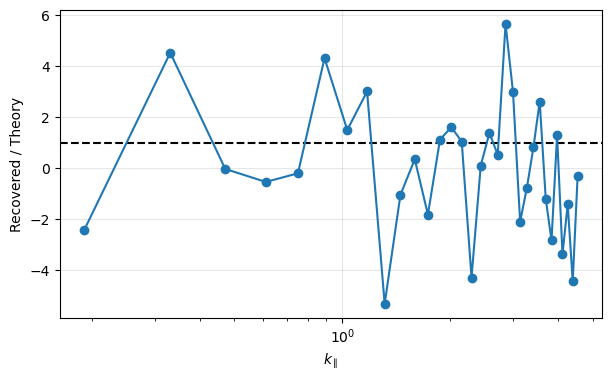

In [13]:
# ----------------------------
# Setup
# ----------------------------
n = 3.0
N = 768
dnuc = 40e-3            # MHz
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

dx = dL

k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model, left=0, right=0)

# correct discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont

def draw_field_from_power(P_dft):
    fk = np.zeros(N, dtype=complex)
    fk[0] = np.sqrt(P_dft[0]) * np.random.randn()
    if N % 2 == 0:
        fk[N//2] = np.sqrt(P_dft[N//2]) * np.random.randn()
    for i in range(1, N//2):
        a, b = np.random.randn(), np.random.randn()
        amp = np.sqrt(P_dft[i]/2)
        fk[i]  = amp*(a + 1j*b)
        fk[-i] = np.conjugate(fk[i])
    return np.fft.ifft(fk).real

# ----------------------------
# Realizations
# ----------------------------
Nrea = 100
fields = np.array([draw_field_from_power(P_dft) for _ in range(Nrea)])

pk_recovered = []

for field in fields:
    fk = np.fft.fft(field)
    pk_fft = (L / N**2) * (fk * fk.conjugate()).real
    pk_recovered.append(pk_fft)

pk_recovered = np.array(pk_recovered)


# binning 
NB = 32  # number of bins

# Build consistent bins based on FFT k-range (skip k=0)
n1 = 10
nend = N//2
k_vals = k_abs[n1:nend]
bins = np.linspace(k_vals.min(), k_vals.max(), NB+1)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# Prepare storage
binned_rec = np.zeros((Nrea, NB))

# --- Bin each realization individually ---
for i in range(Nrea):
    for j in range(NB):
        mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
        if np.any(mask):
            binned_rec[i, j] = np.mean(pk_recovered[i, n1:nend][mask])
        else:
            binned_rec[i, j] = np.nan

# Ensemble statistics
p_rec_mean = np.nanmean(binned_rec, axis=0)
p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)

# --- Bin the theory using the same bins ---
binned_th = np.zeros(NB)
for j in range(NB):
    mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
    if np.any(mask):
        binned_th[j] = np.mean(P_cont[n1:nend][mask])
    else:
        binned_th[j] = np.nan

        
plt.figure(figsize=(7,6))
plt.errorbar(k_centers, abs(p_rec_mean), p_rec_err, fmt='o',ls='--', label='Recovered (mean ± error)')
plt.plot(k_centers, binned_th, '-k', lw=2, label='Theory (window-matched)')
plt.plot(k_centers, k_centers**(-n), '-m', lw=2, label='Theory (window-matched)')
plt.xscale('log');
plt.yscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel(r'$P(k_\parallel)$')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Ratio plot
plt.figure(figsize=(7,4))
plt.axhline(1.0, color='k', ls='--')
err = p_rec_mean / binned_th - 1
plt.plot(k_centers, 100*err, 'o-')
plt.xscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel('Recovered / Theory')
plt.grid(alpha=0.3)
plt.show()


In [7]:
# plt.plot(k_abs[:]+0.01, abs(pk_dct[:]))
# plt.plot(k_abs[:]+0.01, abs(pk_dct1[:]))

# plt.xscale('log')
# plt.yscale('log')

NameError: name 'pk_dct' is not defined

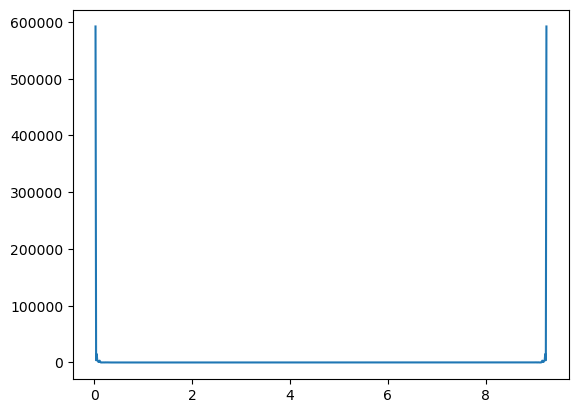

In [8]:
plt.plot(k_abs[1:]+0.01, abs(pk_fft[1:]))
plt.plot(k_dct[1:]+0.01, abs(pk_dct[1:]) )

plt.xscale('log')
plt.yscale('log')

In [ ]:
plt.plot(cl.real)
plt.plot(cl.real*w)


In [ ]:
plt.plot(fields[0]) 
plt.plot(fields[1]) 
plt.plot(fields[2]) 
